# 6.2 Векторизація слів і побудова семантичних уявлень
<a href="https://materials.itstep.org/content/621d8d77-7796-4f67-a150-85d5dc8a2bd8/uk">https://materials.itstep.org/content/621d8d77-7796-4f67-a150-85d5dc8a2bd8/uk</a>

*pip install gensim*

## Бізнес-контекст
Компанія TextMind Analytics досліджує, як користувачі описують свої враження про бренд у соціальних мережах.
Команді потрібно зрозуміти, які слова і вирази близькі за змістом, щоб групувати тексти за темами.
Ваше завдання — побудувати векторні уявлення слів і дослідити їхні семантичні зв'язки за допомогою моделей Word2Vec і GloVe.

Семантичний - мається на увазі "змістовий".
Часто протиставляється "синтаксичному" - безпосередній формі, надпису.
"погана якість", "неякісний", "не відповідає характеристикам" - різні синтаксичні конструкції, але з однаковою семантикою.

Семантична близькість (семантична відстань) вимагає побудову семантичного простору, в якому кожне слово подається вектором (набором семантичних координат). Простір має високу розмірність, відзначаючи різні змістові переходи (осі).

## Завдання 1
Підготуйте корпус текстів.
- Зберіть невеликий набір (10-15 речень) з відгуками або твітами про продукт.
- Приведіть усі тексти до нижнього регістру, видаліть пунктуацію.
- Розділіть тексти на токени і збережіть результат у список списків (кожен підсписок — одне речення).
- Перевірте кількість речень і середню довжину в словах.

In [13]:
feedbacks = {
    "positive": [
        "This product exceeded all my expectations, highly recommended!",
        "Very satisfied with the purchase, the quality is top-notch.",
        "A wonderful device that has made my daily life much easier.",
        "Works fast, stable, and without any complaints.",
        "Perfect value for money, I will definitely buy it again.",
        "Incredibly stylish design and very pleasant materials.",
        "The delivery was mega-fast, and the packaging was completely secure.",
        "I've been using it for a month now and haven't found any downsides yet.",
        "Easy setup, figured it out in minutes without even reading the manual.",
        "The company's service is excellent; the manager helped me choose the right model.",
        "The battery lasts a long time, which was a pleasant surprise for me.",
        "This is the best purchase of the whole year, I sincerely recommend it to everyone!",
        "The ergonomics are great, it's a real pleasure to hold in your hands.",
        "The product runs quietly and very efficiently, I'm thrilled.",
        "The functionality is impressive; it has everything you need for comfortable work.",
        "The manufacturer really paid attention to every detail, excellent build quality.",
        "Compact, lightweight, and very easy to carry around.",
        "The screen is bright, the colors are rich, and the sound is amazing.",
        "Great as a gift or for personal use.",
        "Superb product from a reliable brand, buy it — you won't regret it!",
        "The build quality is exceptionally good, and it feels like a truly premium product.",
        "I've been using it daily, and the battery life is surprisingly good—it easily lasts two full days.",
        "This is a really good value for the money; you get top-tier features without the massive price tag.",
        "The customer support team was so good at helping me set everything up quickly.",
        "It has a very good and intuitive interface, making it perfect for beginners.",
        "The sound clarity is remarkably good, even at higher volumes.",
        "It’s a good, reliable device that does exactly what it promises without any lag.",
        "The ergonomics are fantastic; it provides a really good, comfortable grip.",
        "Shipping was fast, and the item arrived in perfectly good condition.",
        "Overall, it's a great product from a good, trustworthy brand. I highly recommend it!",
    ],
    "negative": [
        "This product broke within the first week of use, absolute waste of money.",
        "Extremely disappointed with the quality, it feels incredibly cheap.",
        "The device constantly freezes and requires a hard reset every single day.",
        "Terrible value for money, it doesn't do half of what was promised.",
        "The design looks completely different from the pictures, very ugly in reality.",
        "Shipping took almost a month, and the box arrived completely crushed.",
        "The setup instructions are impossible to follow, total nightmare to configure.",
        "Customer service was rude and refused to help me with a defective unit.",
        "The battery dies after just one hour of use, which makes it useless for travel.",
        "This is the worst purchase I've made all year, stay away from this brand!",
        "The ergonomics are awful, it's very uncomfortable and painful to hold.",
        "It makes a loud, irritating buzzing noise the entire time it's running.",
        "The software is full of bugs and crashes every time I try to open it.",
        "Missing essential parts right out of the box, terrible quality control.",
        "It is way too heavy and bulky to be considered portable.",
        "The screen is dim, washed out, and impossible to see in daylight.",
        "The material scratches easily and already looks like it's years old.",
        "It overheats significantly after just twenty minutes of standard work.",
        "The features are completely outdated compared to cheaper competitors.",
        "A total disappointment from a brand I used to trust, do not buy it!",
        "The build quality is incredibly bad; it feels like it could break at any moment.",
        "I've had a really bad experience with the battery life—it barely lasts an hour on a full charge.",
        "This is a very bad value for the money; it definitely doesn't justify the high price tag.",
        "The customer support team was so bad at responding to my request for a refund.",
        "It has a very bad and confusing interface, making it almost impossible for beginners to use.",
        "The sound clarity is remarkably bad, with a constant buzzing noise at higher volumes.",
        "It’s a bad, unreliable device that constantly freezes right when you need it most.",
        "The ergonomics are terrible; it leaves you with a really bad, uncomfortable hand cramp.",
        "Shipping was delayed, and the item arrived in a very bad, damaged condition.",
        "Overall, it's a disappointing product from a bad, untrustworthy brand. Save your money!",
    ],
}
# Очистіть текст від пунктуації та приведіть до нижнього регістру.
import re
feedbacks_cleared = {
    "positive": [ re.sub(r"[^\w\s]", "" , f.lower())  for f in feedbacks["positive"]],
    "negative": [ re.sub(r"[^\w\s]", "" , f.lower())  for f in feedbacks["negative"]],
}
import nltk
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize
feedbacks_tokens = {
 "positive": [ word_tokenize(fdbk)  for fdbk in feedbacks_cleared["positive"] ],
 "negative": [ word_tokenize(fdbk)  for fdbk in feedbacks_cleared["negative"] ],
}

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lector\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [14]:
# Перевірте кількість речень і середню довжину в словах.
print("Речень:", len(feedbacks_tokens["positive"]), len(feedbacks_tokens["negative"]))

Речень: 30 30


In [15]:
print("Середня кількість слів у реченні (позитивні відгуки):", 
      sum( (len(sentence) for sentence in feedbacks_tokens["positive"]) ) / 
          len(feedbacks_tokens["positive"]))
print("Середня кількість слів у реченні (негативні відгуки):", 
      sum( (len(sentence) for sentence in feedbacks_tokens["negative"]) ) / 
          len(feedbacks_tokens["negative"]))

Середня кількість слів у реченні (позитивні відгуки): 11.7
Середня кількість слів у реченні (негативні відгуки): 12.9


## Завдання 2
Побудуйте модель Word2Vec.
- Використовуйте бібліотеку gensim.models.Word2Vec.
- Параметри: vector_size = 100, window = 5, min_count = 1, sg = 1.
- Навчіть модель на підготовленому корпусі.
- Виведіть вектор слова good (якщо воно є в корпусі).

In [16]:
from gensim.models import Word2Vec
model = {
    # Навчіть модель на підготовленому корпусі - передача масиву токенів
    k: Word2Vec(sentences=v, vector_size = 100, window = 5, min_count = 1, sg = 1)
    for k,v in feedbacks_tokens.items()
}
model

{'positive': <gensim.models.word2vec.Word2Vec at 0x233ef325590>,
 'negative': <gensim.models.word2vec.Word2Vec at 0x233ef325bd0>}

In [21]:
words = ["good", "bad", "quality"]
for word in words:
    try :
        vector_pos = model["positive"].wv[word][:5]
        print("positive", word, vector_pos, '...')
    except:
        print(f"У позитивних відгуках немає слова '{word}'")
    try :
        vector_neg = model["negative"].wv[word][:5]
        print("negative", word, vector_neg, '...')
    except:
        print(f"У негативних відгуках немає слова '{word}'")

positive good [-0.00964406  0.00254935 -0.00064588 -0.00896543 -0.00938807] ...
У негативних відгуках немає слова 'good'
У позитивних відгуках немає слова 'bad'
negative bad [-0.00806231  0.00185146 -0.00774664 -0.00103008  0.00350508] ...
positive quality [-0.00050671  0.00430273  0.00216796  0.01018307  0.00055257] ...
negative quality [-0.00273782 -0.00590339  0.00743448 -0.00708962 -0.00896036] ...


## Завдання 3
Дослідіть семантичну близькість слів.
- Використовуйте метод most_similar() для пошуку слів, близьких за змістом до good, bad і quality.
- Відобразіть результати в таблиці:

|Цільове слово|Близькі слова|Косинусна схожість|
|-|-|-|
|good|great, nice, amazing|0.91, 0.87, 0.85|
|bad|poor, terrible, awful|0.88, 0.83, 0.81|

Косинусна схожість - математично, косинус кута між векторами слів
у семантичному просторі. Якщо кут 0 (вектори паралельні), то косинус = 1,
якщо перпендикулярні, то 0, якщо антипаралельні (спрямовані в різні боки), то -1.
Для метрик, зазвичай, відємні значення не використовуються, залишаючи 0 - відсутність подібності, 1 - максимальна подібність.

In [24]:
similars = {
    word: [ [], [] ]
    for word in words
}
for word in words:
    try :
        similars[word][0] = model["positive"].wv.most_similar(word, topn=3)
    except:
        similars[word][0] = []
    
    try :
        similars[word][1] = model["negative"].wv.most_similar(word, topn=3)
    except:
        similars[word][1] = []
similars

{'good': [[('clarity', 0.3083684742450714),
   ('exactly', 0.30286651849746704),
   ('quickly', 0.2538871169090271)],
  []],
 'bad': [[],
  [('from', 0.28611963987350464),
   ('making', 0.2783631682395935),
   ('setup', 0.2659761607646942)]],
 'quality': [[('definitely', 0.23883885145187378),
   ('found', 0.2319725900888443),
   ('secure', 0.21585756540298462)],
  [('worst', 0.25967440009117126),
   ('one', 0.2454453408718109),
   ('just', 0.22383643686771393)]]}

In [31]:
from IPython.display import Markdown as md
md("\n".join((
    "|Слово|Позитивні|Негативні|",
    "|-|-|-|",
    *( "|%s|%s|%s|" % (
        k,
        *(", ".join((f"{ws[0]} ({ws[1]:.2f})" for ws in v[i])) for i in (0,1)),
        # ", ".join((f"{ws[0]} ({ws[1]:.2f})" for ws in v[1])),
    ) for k,v in similars.items() )
)))

|Слово|Позитивні|Негативні|
|-|-|-|
|good|clarity (0.31), exactly (0.30), quickly (0.25)||
|bad||from (0.29), making (0.28), setup (0.27)|
|quality|definitely (0.24), found (0.23), secure (0.22)|worst (0.26), one (0.25), just (0.22)|

## Завдання 4
Візуалізуйте зв'язки між словами.
- Виберіть 20 найчастіших слів корпусу.
- Отримайте їхні векторні подання з моделі Word2Vec.
- Зменшіть розмірність до 2D за допомогою sklearn.decomposition.PCA.
- Побудуйте scatter-графік, де кожна точка — слово.
- Підпишіть точки та збережіть графік у файл word2vec_visualization.png.
- Порівняйте результати Word2Vec з переднавченими векторами GloVe (доступні через gensim.downloader.load('glove-wiki-gigaword-100')).
- Визначте, які пари слів найбільш схожі за змістом в обох моделях

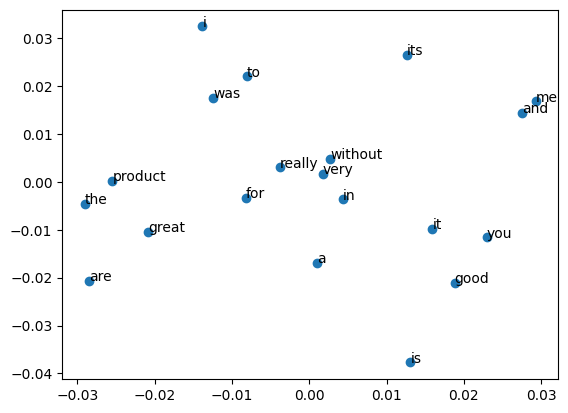

In [36]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

words_pos = model["positive"].wv.index_to_key[:20]  # Виберіть 20 найчастіших слів корпусу.
wv_pos = model["positive"].wv[words_pos]            # Отримайте їхні векторні подання з моделі Word2Vec.
pca = PCA(n_components=2)                           # за допомогою sklearn.decomposition.PCA.
space2d = pca.fit_transform(wv_pos)                 # Зменшіть розмірність до 2D

fig, ax = plt.subplots()                            # Побудуйте scatter-графік,
ax.scatter(space2d[:,0], space2d[:,1])              #  де кожна точка — слово.
for i, w in enumerate(list(words_pos)):
    ax.annotate(w, xy=(space2d[i,0], space2d[i,1])) # Підпишіть точки
plt.show()
fig.savefig("word2vec_visualization.png")

In [40]:
# Порівняйте результати Word2Vec з переднавченими векторами GloVe 
# (доступні через gensim.downloader.load('glove-wiki-gigaword-100')).
import gensim.downloader as gdl

glove = gdl.load('glove-wiki-gigaword-100')

In [41]:
for word in words:
    print(word, glove.most_similar(word, topn=3))

good [('better', 0.893191397190094), ('sure', 0.8314563035964966), ('really', 0.8297762274742126)]
bad [('worse', 0.7929712533950806), ('good', 0.7702797651290894), ('things', 0.7653602957725525)]
quality [('excellent', 0.7606267929077148), ('standards', 0.7328648567199707), ('performance', 0.7243241667747498)]


In [44]:
md("\n".join((
    "|Слово|Позитивні|Негативні|glove|",
    "|-|-|-|-|",
    *( "|%s|%s|%s|%s|" % (
        k,
        *(", ".join((f"{ws[0]} ({ws[1]:.2f})" for ws in v[i])) for i in (0,1)),
        # ", ".join((f"{ws[0]} ({ws[1]:.2f})" for ws in v[1])),
        ", ".join((f"{ws[0]} ({ws[1]:.2f})" for ws in glove.most_similar(k, topn=3)))
    ) for k,v in similars.items() ),    
)))

|Слово|Позитивні|Негативні|glove|
|-|-|-|-|
|good|clarity (0.31), exactly (0.30), quickly (0.25)||better (0.89), sure (0.83), really (0.83)|
|bad||from (0.29), making (0.28), setup (0.27)|worse (0.79), good (0.77), things (0.77)|
|quality|definitely (0.24), found (0.23), secure (0.22)|worst (0.26), one (0.25), just (0.22)|excellent (0.76), standards (0.73), performance (0.72)|